# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Refuerzo, Paul Adam
- _Student No._: 2024-09465
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Description](GraphOfFunction.png)
Figure 1.

![Description](ConvergenceOfRoots.png)
Figure 2.

### Report discussion

The plots above show how different root finding methods converge to the roots of the function $f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8$. It shows that the fixed point method fails diverges quickly for many initial x values. This is likely because of the ill conditioning of the provided function, having steep plots around the roots as can be seen in figure 1. The bisection method also suffers a loss of accuracy for the middle root. Aside from those, the bisection, newton and secant methods converge to the desired roots.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [2]:
def fixedpoint(g, xold, kmax=200, tol=1.e-8):
    x_is = np.zeros(kmax)
    for k in range(1, kmax):
        xnew = f(xold)
        
        if abs(xnew - xold) < tol:
            x_is[k:] = xnew
            return xnew, x_is

        xold = xnew  
        x_is[k] = xnew
    else:
        return None, x_is

In [3]:
def bisection(f, x1, x2, kmax=200, tol=1.e-8):
    x_is = np.zeros(kmax)
    for k in range(1, kmax):
        f1 = f(x1)
        f2 = f(x2)

        xmid = (x1+x2)/2
        fmid = f(xmid)
        
        if fmid*f1 < 0:
            x2 = xmid
        else:
            x1 = xmid

        xmidnew = (x1+x2)/2
        xdiff = abs(xmidnew-xmid)

        if abs(xdiff/xmidnew) < tol:
            x_is[k:] = xmidnew
            return xmidnew, x_is

        x_is[k] = xmidnew
    else:
        return None, x_is

In [4]:
def newton(f, df, xold, kmax=200, tol=1.e-8):
    x_is = np.zeros(kmax)
    for k in range(1, kmax):
        xnew = xold - f(xold) / df(xold)
        
        if abs(xnew - xold) < tol:
            x_is[k:] = xnew
            return xnew, x_is

        xold = xnew
        x_is[k] = xnew
    else:
        return None, x_is

In [5]:
def secant(f, x1, x2, kmax=200, tol=1.e-8):
    x_is = np.zeros(kmax)
    for k in range(1, kmax):
        f1 = f(x1)
        f2 = f(x2)
            
        xnew = x2 - f2 * (x2 - x1) / (f2 - f1)
        
        if abs(xnew - x2) < tol:
            x_is[k:] = xnew
            return xnew, x_is
            
        x1, x2 = x2, xnew
        x_is[k] = xnew
    else:
        return None, x_is

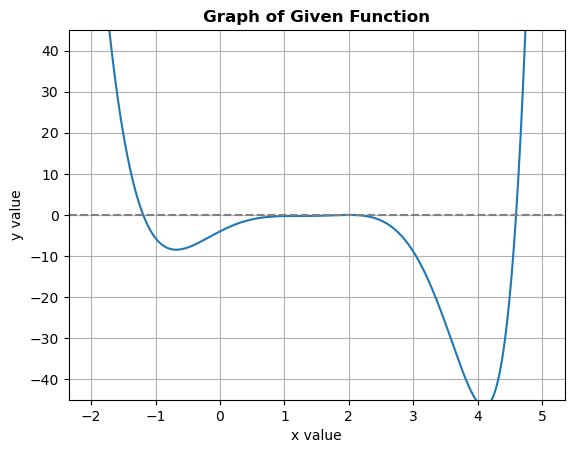

In [6]:
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + x**2*np.exp(x) - 2*x*np.exp(x)

xs = np.linspace(-2, 5, 400)
ys = f(xs)

plt.plot(xs, ys)
plt.title('Graph of Given Function', fontweight='bold')
plt.ylim(-45, 45)
plt.xlabel('x value')
plt.ylabel('y value')
plt.axhline(y=0, color='gray', linestyle='--')
plt.grid()
plt.show()

In [7]:
print('Roots from fixed point method:')

for xolds in range(-2, 5):
    fixedpointroot, _ = fixedpoint(f, xolds)
    if fixedpointroot != None:
        print(f"\tinitial guess ({xolds}): {fixedpointroot}")
    else:
        print(f"\tDoes not converge for initial guess({xolds})")

print('Roots from bisection method:')

for x1s in range(-2, 5):
    bisectionroot, _ = bisection(f, x1s, x1s+3)
    if bisectionroot != None:
        print(f"\tbounds({x1s}, {x1s+3}): {bisectionroot}")
    else:
        print(f"\tDoes not converge for bounds({x1s}, {x1s + 3}) ({xolds})")

print('Roots from Newton-Raphson method:')

for xolds in range(-2, 5):
    newtonroot, _ = newton(f, df, xolds)
    if newtonroot != None:
        print(f"\tinitial guess ({xolds}): {newtonroot}")
    else:
        print(f"\tDoes not converge for initial guess({xolds})")

print('Roots from Secant method:')

for x1s in range(-2, 5):
    secantroot, _ = secant(f, x1s, x1s + 1)
    if secantroot != None:
        print(f"\tguesses ({x1s}, {x1s + 1}): {secantroot}")
    else:
        print(f"\tDoes not converge for guesses({x1s}, {x1s + 1})")

Roots from fixed point method:
	Does not converge for initial guess(-2)
	Does not converge for initial guess(-1)
	Does not converge for initial guess(0)
	Does not converge for initial guess(1)
	Does not converge for initial guess(2)
	Does not converge for initial guess(3)
	Does not converge for initial guess(4)
Roots from bisection method:
	bounds(-2, 1): -1.1926857642829418
	bounds(-1, 2): 1.9999999664723873
	bounds(0, 3): 2.999999977648258
	bounds(1, 4): 3.999999977648258
	bounds(2, 5): 4.595863565802574
	bounds(3, 6): 4.595863536000252
	bounds(4, 7): 4.5958635956048965
Roots from Newton-Raphson method:
	initial guess (-2): -1.1926857650225988
	initial guess (-1): -1.1926857650225988
	initial guess (0): 4.595863564922455
	initial guess (1): 2.0000000430186224
	Does not converge for initial guess(2)
	initial guess (3): 1.9999999906895738
	initial guess (4): 1.9999999656818783
Roots from Secant method:
	guesses (-2, -1): -1.1926857650225988
	guesses (-1, 0): 2.0000000577236703
	guesses

/tmp/ipykernel_402032/2924494544.py:2: RuntimeWarning: overflow encountered in exp
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
/tmp/ipykernel_402032/2924494544.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
/tmp/ipykernel_402032/2743971299.py:4: RuntimeWarning: invalid value encountered in scalar divide
  xnew = xold - f(xold) / df(xold)


/tmp/ipykernel_402032/2924494544.py:2: RuntimeWarning: overflow encountered in exp
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
/tmp/ipykernel_402032/2924494544.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8


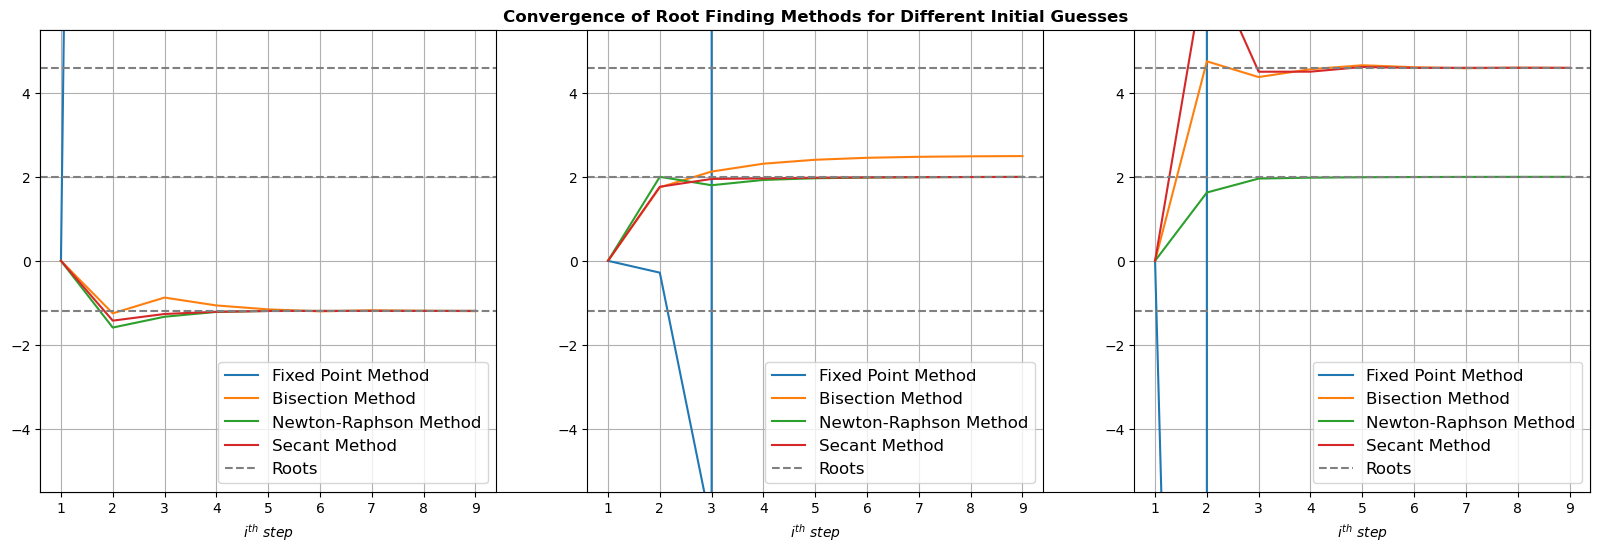

In [9]:
i_vals = np.arange(1, 10)

plt.figure(figsize=(20, 6))
plt.xticks([])
plt.yticks([])
plt.title('Convergence of Root Finding Methods for Different Initial Guesses', fontweight='bold')
for input, x in enumerate([-2, 1, 4]):
    _ , xfixpt = fixedpoint(f, x, kmax=len(i_vals))
    _ , xbisect = bisection(f, x-1.5, x+1.5, kmax=len(i_vals))
    _ , xnewton = newton(f, df, x, kmax=len(i_vals))
    _ , xsecant = secant(f, x-0.5, x+0.5, kmax=len(i_vals))

    plt.subplot(1, 3, input+1)
    plt.plot(i_vals, xfixpt, label='Fixed Point Method')
    plt.plot(i_vals, xbisect, label='Bisection Method')
    plt.plot(i_vals, xnewton, label='Newton-Raphson Method')
    plt.plot(i_vals, xsecant, label='Secant Method')
    plt.ylim(-5.5, 5.5)
    plt.xlabel('$i^{th}$ $step$')
    plt.axhline(y=-1.192, color='gray', linestyle='--', label='Roots')
    plt.axhline(y=2, color='gray', linestyle='--')
    plt.axhline(y=4.59, color='gray', linestyle='--')
    plt.legend(fontsize='12', loc='lower right')
    plt.grid()

plt.savefig('ConvergenceOfRoots', dpi=300)
plt.show()

#### Problem 1 code summary

The code above defines four methods for numerically calculating the roots of a given function, as well as plot how they approach the root values for each iteration the method uses. The functions each returns two outputs, the final root value at the last iteration and an array of the calculated value per iteration to be used for the plotting. It makes use of several for loops to test the methods using several initial guesses in order to find all the roots of the given function.

---